## Q2 — covariate shift detector

Setup: fixed concept $y = \mathbf{1}[x_2 > x_1^2 - 1]$, source $x \sim \mathcal{N}((-1.5, 1.25), I)$, target $x \sim \mathcal{N}((1.5, 1.25), I)$ — $p(x)$ shifts, $p(y|x)$ doesn't. Detector: classify source-vs-target inputs; holdout accuracy $\gg 0.5$ means shift.

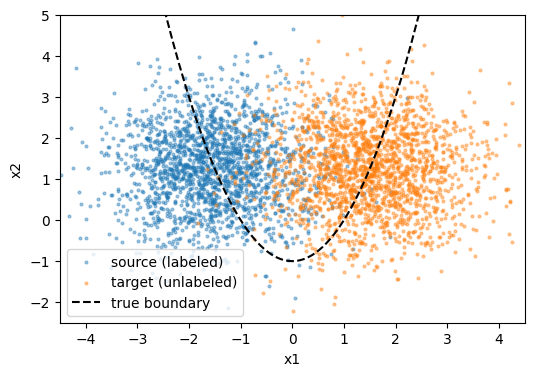

In [4]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
label = lambda X: (X[:, 1] > X[:, 0]**2 - 1).float()   # true concept, same in both domains
sample = lambda cx, n: torch.randn(n, 2) + torch.tensor([cx, 1.25])

X_src, X_tgt, X_test = sample(-1.5, 2000), sample(1.5, 2000), sample(1.5, 4000)
y_src, y_test = label(X_src), label(X_test)   # target labels: evaluation only

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(*X_src.T, s=4, alpha=0.4, label="source (labeled)")
ax.scatter(*X_tgt.T, s=4, alpha=0.4, label="target (unlabeled)")
xs = torch.linspace(-4, 4, 200)
ax.plot(xs, xs**2 - 1, "k--", lw=1.5, label="true boundary")
ax.set(xlim=(-4.5, 4.5), ylim=(-2.5, 5), xlabel="x1", ylabel="x2")
ax.legend()
plt.show()

In [5]:
def train_logreg(X, y, weights=None, epochs=500, lr=0.5):
    torch.manual_seed(1)
    w, b = torch.zeros(2, requires_grad=True), torch.zeros(1, requires_grad=True)
    weights = torch.ones(len(X)) if weights is None else weights
    weights = weights / weights.sum()
    for _ in range(epochs):
        loss = (weights * torch.nn.functional.binary_cross_entropy_with_logits(
            X @ w + b, y, reduction="none")).sum()
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad; b -= lr * b.grad
            w.grad.zero_(); b.grad.zero_()
    return w.detach(), b.detach()

def accuracy(w, b, X, y):
    return (((X @ w + b) > 0).float() == y).float().mean().item()

def detect_shift(Xa, Xb):
    """Two-sample test via a domain classifier (Xa -> 0, Xb -> 1).
    Returns its holdout accuracy: ~0.5 = same distribution, >> 0.5 = shift."""
    X = torch.cat([Xa, Xb]); domain = torch.cat([torch.zeros(len(Xa)), torch.ones(len(Xb))])
    idx = torch.randperm(len(X)); X, domain = X[idx], domain[idx]
    n_tr = int(0.7 * len(X))
    w, b = train_logreg(X[:n_tr], domain[:n_tr])
    return accuracy(w, b, X[n_tr:], domain[n_tr:]), (w, b)

torch.manual_seed(42)
detector_acc, (w_det, b_det) = detect_shift(X_src, X_tgt)   # source vs target
control_acc, _ = detect_shift(X_src[:1000], X_src[1000:])   # same dist: sanity check
print(f"domain-classifier acc, src vs tgt: {detector_acc:.3f}  (chance 0.5 +- {0.5/1200**0.5:.3f} -> SHIFT)")
print(f"domain-classifier acc, src vs src: {control_acc:.3f}  (no-shift control)")

domain-classifier acc, src vs tgt: 0.932  (chance 0.5 +- 0.014 -> SHIFT)
domain-classifier acc, src vs src: 0.485  (no-shift control)


## Q3 — covariate shift corrector

Importance weights from the detector's logit: $\beta(x) = e^{h(x)} \approx p_T(x)/p_S(x)$ (equal sample sizes). Retrain on source with per-sample weights $\beta_i$, clipped at the 99th percentile.

ESS = 113 / 2000
task acc on target, unweighted: 0.492   (on source: 0.966)
task acc on target, weighted  : 0.973


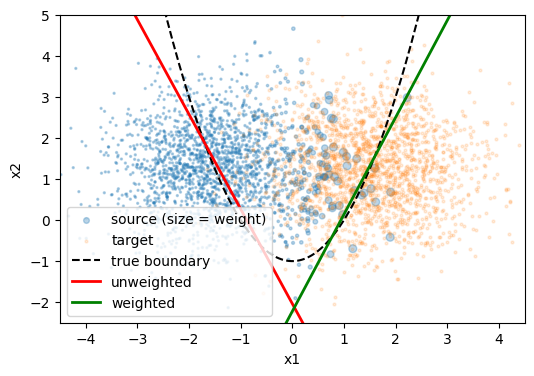

In [6]:
beta = torch.exp(X_src @ w_det + b_det)              # density ratio from detector logit
beta = torch.clamp(beta, max=torch.quantile(beta, 0.99))
print("ESS = %.0f / %d" % (beta.sum()**2 / (beta**2).sum(), len(beta)))

w0, b0 = train_logreg(X_src, y_src)                  # plain ERM
w1, b1 = train_logreg(X_src, y_src, weights=beta)    # importance-weighted ERM
print(f"task acc on target, unweighted: {accuracy(w0, b0, X_test, y_test):.3f}   (on source: {accuracy(w0, b0, X_src, y_src):.3f})")
print(f"task acc on target, weighted  : {accuracy(w1, b1, X_test, y_test):.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(*X_src.T, s=2 + 30 * beta / beta.max(), alpha=0.3, label="source (size = weight)")
ax.scatter(*X_tgt.T, s=4, alpha=0.15, label="target")
xs = torch.linspace(-4, 4, 200)
ax.plot(xs, xs**2 - 1, "k--", lw=1.5, label="true boundary")
for (w, b), style, name in [((w0, b0), "r-", "unweighted"), ((w1, b1), "g-", "weighted")]:
    ax.plot(xs, -(w[0] * xs + b) / w[1], style, lw=2, label=name)
ax.set(xlim=(-4.5, 4.5), ylim=(-2.5, 5), xlabel="x1", ylabel="x2")
ax.legend()
plt.show()

Detector: 0.93 vs 0.49 control — shift detected exactly when present. Corrector: the linear model fits the parabola's local tangent, so plain ERM scores 0.97 at home but 0.49 on target; weighting by $\beta$ moves the fit to where the target lives → 0.97 on target. Cost: ESS drops to ~113/2000 ($1/\sum \beta_i^2$ effective samples) — importance weighting trades variance for bias, and dies entirely without support overlap.